In [1]:
# Instalasi dan import library yang diperlukan
%pip install Sastrawi nltk scikit-learn pandas wordcloud

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Unduh daftar stopwords Bahasa Indonesia dari NLTK
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from wordcloud import WordCloud



Note: you may need to restart the kernel to use updated packages.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
DATA_PATH = 'dataset_duolingo.csv'

# Memuat dataset ulasan pengguna aplikasi Duolingo
df = pd.read_csv(DATA_PATH)

print("Jumlah data:", len(df))
df.head()


Jumlah data: 10000


,user_name,score,content
0,Naufal Atha S,4,Bagus sih tapi kadang pas udah nyelesain malah...
1,Ni Made Shinta Hardiyanti bendesemas,5,Aplikasi yang paling bagus banget saya bisa be...
2,Desmiati Buke,5,duolinggo ini belajarnya seru apa lagi di catu...
3,Khoirul Codo,5,membantu saya belajar
4,BAYU SYAH PUTRA,1,Gk ada catur terus betanya penuh please klo ma...


In [3]:
# Fungsi untuk explorasi data

def explore_data(df):
  print('Info dataset:')
  display(df.info())

  print('\nMissing values:')
  display(df.isna().sum().to_frame('missing_count'))

  print('\nDistribusi score (count):')
  score_count = df['score'].value_counts(dropna=False).sort_index()
  display(score_count.to_frame('count'))

  print('\nDistribusi score (persentase):')
  score_pct = (df['score'].value_counts(normalize=True, dropna=False).sort_index() * 100).round(2)
  display(score_pct.to_frame('pct'))

  fig, axes = plt.subplots(1, 2, figsize=(14, 5))

  sns.countplot(data=df, x='score', hue='score', order=sorted(df['score'].dropna().unique()), ax=axes[0], palette='viridis')
  axes[0].set_title('Distribusi Score (Count)')
  axes[0].set_xlabel('Score')
  axes[0].set_ylabel('Jumlah')

  axes[1].pie(score_count.values, labels=[str(x) for x in score_count.index], autopct='%1.1f%%', startangle=90)
  axes[1].set_title('Distribusi Score (Persentase)')

  plt.tight_layout()
  plt.show()

  # Distribusi panjang karakter content
  df['char_len'] = df['content'].astype(str).str.len()

  plt.figure(figsize=(10, 4))
  sns.histplot(df['char_len'], bins=40, kde=True, color='teal')
  plt.title('Distribusi Panjang Ulasan (Jumlah Karakter)')
  plt.xlabel('Jumlah Karakter')
  plt.ylabel('Frekuensi')
  plt.show()

Info dataset:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   user_name  10000 non-null  str  
 1   score      10000 non-null  int64
 2   content    10000 non-null  str  
dtypes: int64(1), str(2)
memory usage: 234.5 KB


None


Missing values:


,missing_count
user_name,0
score,0
content,0



Distribusi score (count):


,count
score,
1,485
2,180
3,350
4,1050
5,7935



Distribusi score (persentase):


,pct
score,
1,4.85
2,1.80
3,3.50
4,10.50
5,79.35


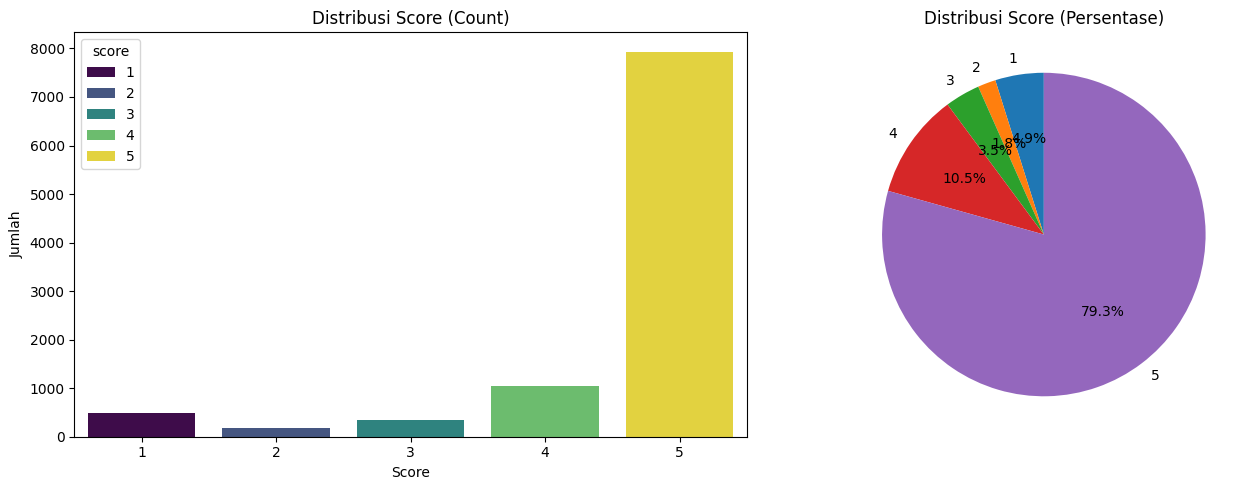

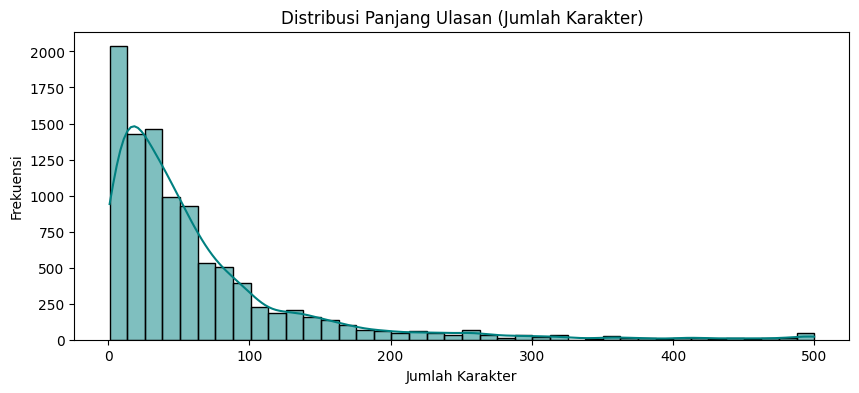

In [4]:
# copy dataset menjadi clean_df
clean_df = df.copy()

# menampilkan kembali data yang sudah dibersihkan
explore_data(clean_df)

In [5]:
# Pastikan kolom score berupa numerik
clean_df['score'] = pd.to_numeric(clean_df['score'], errors='coerce')

# Pastikan kolom score berupa angka valid 1 sampai 5
clean_df = clean_df[clean_df['score'].between(1, 5)]
clean_df['score'] = clean_df['score'].astype(int)

print('Shape sesudah filtering:', clean_df.shape)
display(clean_df.head())

Shape sesudah filtering: (10000, 4)


,user_name,score,content,char_len
0,Naufal Atha S,4,Bagus sih tapi kadang pas udah nyelesain malah...,197
1,Ni Made Shinta Hardiyanti bendesemas,5,Aplikasi yang paling bagus banget saya bisa be...,78
2,Desmiati Buke,5,duolinggo ini belajarnya seru apa lagi di catu...,290
3,Khoirul Codo,5,membantu saya belajar,21
4,BAYU SYAH PUTRA,1,Gk ada catur terus betanya penuh please klo ma...,124


In [6]:
# Proses pembersihan teks mentah: 
def clean_text(text: str) -> str:
    text = str(text).lower() # ubah jadi lowercase
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text) # hapus teks yang berupa URL
    text = re.sub(r'[^a-z\s]', ' ', text) # hapus text selain huruf
    text = re.sub(r'\s+', ' ', text).strip() # hapus spasi berlebih
    return text

clean_df['clean_content'] = clean_df['content'].apply(clean_text)
clean_df[['content', 'clean_content']].head()


,content,clean_content
0,Bagus sih tapi kadang pas udah nyelesain malah...,bagus sih tapi kadang pas udah nyelesain malah...
1,Aplikasi yang paling bagus banget saya bisa be...,aplikasi yang paling bagus banget saya bisa be...
2,duolinggo ini belajarnya seru apa lagi di catu...,duolinggo ini belajarnya seru apa lagi di catu...
3,membantu saya belajar,membantu saya belajar
4,Gk ada catur terus betanya penuh please klo ma...,gk ada catur terus betanya penuh please klo ma...


In [7]:
# Normalisasi kata tidak baku dan singkatan yang sering muncul di ulasan aplikasi
SLANGWORDS = {
    'gk': 'tidak', 'ga': 'tidak', 'nggak': 'tidak', 'gak': 'tidak',
    'bgt': 'banget', 'bener': 'benar', 'nyesel': 'menyesal',
    'mantul': 'mantap', 'trima': 'terima', 'smoga': 'semoga',
    'kmu': 'kamu', 'udh': 'sudah', 'sdh': 'sudah',
    'tp': 'tapi', 'jd': 'jadi', 'dgn': 'dengan', 'blm': 'belum',
    'trs': 'terus', 'bkn': 'bukan', 'yg': 'yang',
    'kr': 'karena', 'krn': 'karena', 'dpt': 'dapat', 'hrs': 'harus',
    'bnr': 'benar', 'knp': 'kenapa', 'bs': 'bisa', 'ttg': 'tentang',
    'jgn': 'jangan', 'skrg': 'sekarang', 'lv': 'level', 'app': 'aplikasi'
}

def normalize_text(text: str) -> str:
    return ' '.join([SLANGWORDS.get(w, w) for w in text.split()])

clean_df['clean_content'] = clean_df['clean_content'].apply(normalize_text)
clean_df[['content', 'clean_content']].head()


,content,clean_content
0,Bagus sih tapi kadang pas udah nyelesain malah...,bagus sih tapi kadang pas udah nyelesain malah...
1,Aplikasi yang paling bagus banget saya bisa be...,aplikasi yang paling bagus banget saya bisa be...
2,duolinggo ini belajarnya seru apa lagi di catu...,duolinggo ini belajarnya seru apa lagi di catu...
3,membantu saya belajar,membantu saya belajar
4,Gk ada catur terus betanya penuh please klo ma...,tidak ada catur terus betanya penuh please klo...


In [8]:
def tokenizing_text(text: str):
  text = word_tokenize(text)
  return text

# Tokenisasi, penghapusan stopwords, dan stemming menggunakan Sastrawi
stopwords_indonesia = set(stopwords.words('indonesian'))

sastrawi_factory = StemmerFactory()
stemmer = sastrawi_factory.create_stemmer()

def process_text(text):
    if not isinstance(text, str):
      return ''
  
    tokenized_text = tokenizing_text(text)
    tokens = [w for w in tokenized_text if w not in stopwords_indonesia]
    stems = [stemmer.stem(w) for w in tokens]
    return ' '.join(stems)

clean_df['clean_content'] = clean_df['clean_content'].apply(process_text)
clean_df[['content', 'clean_content']].head()


,content,clean_content
0,Bagus sih tapi kadang pas udah nyelesain malah...,bagus sih kadang pas udah nyelesain layar puti...
1,Aplikasi yang paling bagus banget saya bisa be...,aplikasi bagus banget ajar bahasa inggris
2,duolinggo ini belajarnya seru apa lagi di catu...,duolinggo ajar seru catur lawan oscar lawan or...
3,membantu saya belajar,bantu ajar
4,Gk ada catur terus betanya penuh please klo ma...,catur beta penuh please klo bikin tuh marah su...


In [22]:
# Lexicon
LEXICON = {
    "positive": {
        "bagus","mantap","puas","cepat","nyaman","baik","keren","berfungsi",
        "sesuai","memuaskan","top","oke","responsif","ramah","tepat","aman","senang",
        "interaktif","menyenangkan","mudah","lancar","efektif","seru","bermanfaat",
        "lengkap","inovatif","menarik","praktis"
    },
    "negative": {
        "buruk","kecewa","lemot","lambat","error","parah","jelek","mengecewakan",
        "rusak","telat","bohong","tipu","lama","hang","crash","bug",
        "down","ribet","susah","gagal","lemotnya","tidakfungsi",
        "membosankan","sulit","berat","berulang","menjemukan","terbatas","bermasalah"
    }
}

INTENSIFIER = {"sangat","banget","sekali","sungguh","makin","tambah"}
NEGATOR = {"tidak", "bukan", "kurang", "jarang", "sulit", "susah"}

def compute_sentiment(tokens):
    score = 0
    i = 0

    while i < len(tokens):
        word = tokens[i]

        base_score = 0
        if word in LEXICON["positive"]:
            base_score = 1
        elif word in LEXICON["negative"]:
            base_score = -1

        # cek negasi (1 step sebelum)
        if i > 0 and tokens[i-1] in NEGATOR:
            base_score *= -1

        # cek intensifier (1 step sebelum)
        if i > 0 and tokens[i-1] in INTENSIFIER:
            base_score *= 2

        score += base_score
        i += 1

    return score


def label_sentiment(text):
    if not isinstance(text, str):
        return "netral"

    tokens = text.split() # hapus spasi tidak perlu
    score = compute_sentiment(tokens)

    if score > 0:
        return "positive"
    elif score < 0:
        return "negative"
    return "neutral"


# Apply ke dataframe
clean_df['sentiment'] = clean_df['clean_content'].apply(label_sentiment)

# Result
print(clean_df['sentiment'].value_counts())
clean_df[['content', 'clean_content', 'sentiment']].head()

sentiment
neutral     5070
positive    4780
negative     150
Name: count, dtype: int64


,content,clean_content,sentiment
0,Bagus sih tapi kadang pas udah nyelesain malah...,bagus sih kadang pas udah nyelesain layar puti...,positive
1,Aplikasi yang paling bagus banget saya bisa be...,aplikasi bagus banget ajar bahasa inggris,positive
2,duolinggo ini belajarnya seru apa lagi di catu...,duolinggo ajar seru catur lawan oscar lawan or...,positive
3,membantu saya belajar,bantu ajar,neutral
4,Gk ada catur terus betanya penuh please klo ma...,catur beta penuh please klo bikin tuh marah su...,neutral


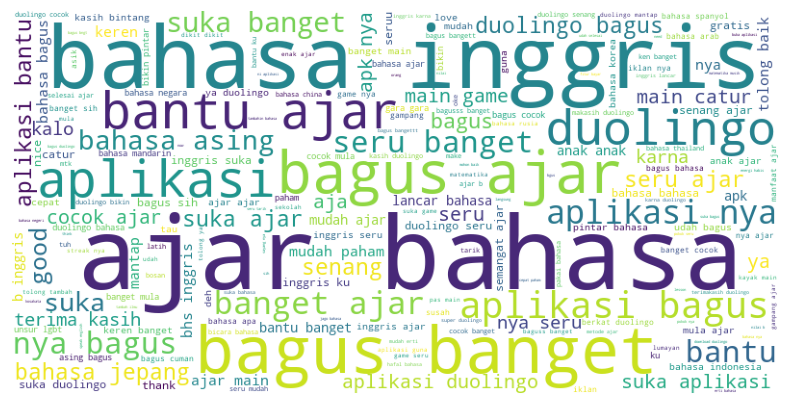

In [23]:
# melihat wordcloud seluruh kolom clean_content
all_text = ' '.join(clean_df['clean_content'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

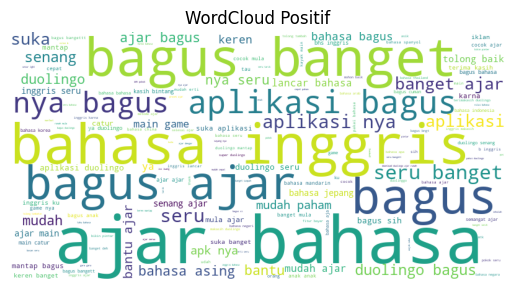

In [24]:
# wordcloud sentiment positive
text_pos = ' '.join(clean_df[clean_df['sentiment']=='positive']['clean_content'])

wc_pos = WordCloud(width=800, height=400, background_color='white').generate(text_pos)

plt.imshow(wc_pos)
plt.axis('off')
plt.title('WordCloud Positif')
plt.show()

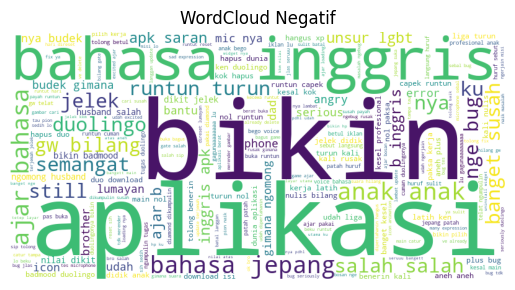

In [25]:
# wordcloud sentiment negative
text_pos = ' '.join(clean_df[clean_df['sentiment']=='negative']['clean_content'])

wc_pos = WordCloud(width=800, height=400, background_color='white').generate(text_pos)

plt.imshow(wc_pos)
plt.axis('off')
plt.title('WordCloud Negatif')
plt.show()

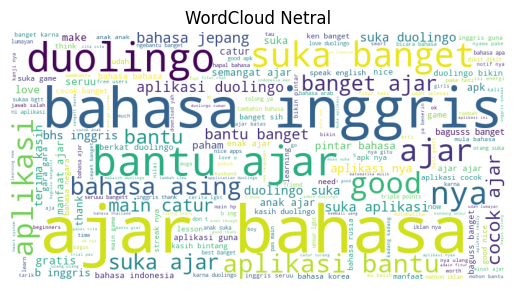

In [26]:
# wordcloud sentiment neutral
text_pos = ' '.join(clean_df[clean_df['sentiment']=='neutral']['clean_content'])

wc_pos = WordCloud(width=800, height=400, background_color='white').generate(text_pos)

plt.imshow(wc_pos)
plt.axis('off')
plt.title('WordCloud Netral')
plt.show()

In [27]:
# Pembagian data menjadi set pelatihan (80%) dan pengujian (20%) dengan stratifikasi label
from sklearn.model_selection import train_test_split

X = clean_df['clean_content']
y = clean_df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Data latih :", len(X_train))
print("Data uji   :", len(X_test))


Data latih : 8000
Data uji   : 2000


In [28]:
# Ekstraksi fitur menggunakan TF-IDF dengan kombinasi unigram dan bigram
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print("Shape TF-IDF:")
print("Train:", X_train_tfidf.shape)
print("Test :", X_test_tfidf.shape)


Shape TF-IDF:
Train: (8000, 5000)
Test : (2000, 5000)


In [29]:
# Fungsi evaluasi model

def evaluate_model(model, X_test, y_test, model_name=None, verbose=True):
    pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, pred)
    macro_f1 = f1_score(y_test, pred, average='macro')
    
    if verbose:
        print(f"\n=== {model_name} ===")
        print(f"Akurasi: {acc*100:.2f}%  |  Macro F1: {macro_f1:.4f}")
        print(classification_report(y_test, pred))
    
    return {
        "accuracy": acc,
        "macro_f1": macro_f1
    }

In [30]:
# Loop dan training model
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, C=1.5),
    "SVM": LinearSVC(C=0.8),
    "Naive Bayes": MultinomialNB(alpha=0.5)
}

results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    
    metrics = evaluate_model(
        model,
        X_test_tfidf,
        y_test,
        model_name=name
    )
    
    results[name] = metrics["macro_f1"]


=== Logistic Regression ===
Akurasi: 99.70%  |  Macro F1: 0.9809
              precision    recall  f1-score   support

    negative       1.00      0.90      0.95        30
     neutral       1.00      1.00      1.00      1014
    positive       1.00      1.00      1.00       956

    accuracy                           1.00      2000
   macro avg       1.00      0.97      0.98      2000
weighted avg       1.00      1.00      1.00      2000


=== SVM ===
Akurasi: 99.85%  |  Macro F1: 0.9886
              precision    recall  f1-score   support

    negative       0.94      1.00      0.97        30
     neutral       1.00      1.00      1.00      1014
    positive       1.00      1.00      1.00       956

    accuracy                           1.00      2000
   macro avg       0.98      1.00      0.99      2000
weighted avg       1.00      1.00      1.00      2000


=== Naive Bayes ===
Akurasi: 96.15%  |  Macro F1: 0.7981
              precision    recall  f1-score   support

    negat

In [31]:
# Fungsi pilih model terbaik
def get_best_model(models, results):
    best_name = max(results, key=results.get)
    return best_name, models[best_name], results[best_name]

In [32]:
best_model_name, best_model, best_score = get_best_model(models, results)

print(f"\nModel terbaik: {best_model_name} (Macro F1: {best_score:.4f})")


Model terbaik: SVM (Macro F1: 0.9886)


In [33]:
# Pengujian model terbaik terhadap kalimat baru menggunakan pipeline preprocessing yang sama

def analisis_sentimen(teks):
    teks = clean_text(teks)
    teks = normalize_text(teks)
    teks = process_text(teks)
    X_new = vectorizer.transform([teks])
    return best_model.predict(X_new)[0]

# Contoh ulasan khas pengguna aplikasi Duolingo
contoh = [
    "Aplikasi Duolingo sangat menyenangkan, pelajaran bahasa Inggrisnya mudah diikuti!",
    "Streak sering hilang padahal sudah belajar, fitur notifikasinya bermasalah.",
    "Level-nya membosankan dan materi yang diulang terus terasa tidak efektif."
]

for c in contoh:
    print(f"{c}\n-> {analisis_sentimen(c)}\n")


Aplikasi Duolingo sangat menyenangkan, pelajaran bahasa Inggrisnya mudah diikuti!
-> positive

Streak sering hilang padahal sudah belajar, fitur notifikasinya bermasalah.
-> neutral

Level-nya membosankan dan materi yang diulang terus terasa tidak efektif.
-> positive



In [34]:
# Mencatat dependensi library yang digunakan
!pip freeze > requirements.txt
print("File 'requirements.txt' berhasil dibuat.")


File 'requirements.txt' berhasil dibuat.
